## 50 Startups Profit Prediction using Multiple Linear Regression

## Objective
To build a predictive model to estimate profit based on:
- R&D Spend
- Administration
- Marketing Spend
- State

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

In [2]:
df = pd.read_csv(r"C:\Users\mahesh\Documents\Assignment_2\50_Startups.csv")
df.head(3)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39


In [3]:
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


#### Data Cleaning

In [4]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

#### No Missing Values Found
- Dataset is clean and ready for analysis.

### EDA

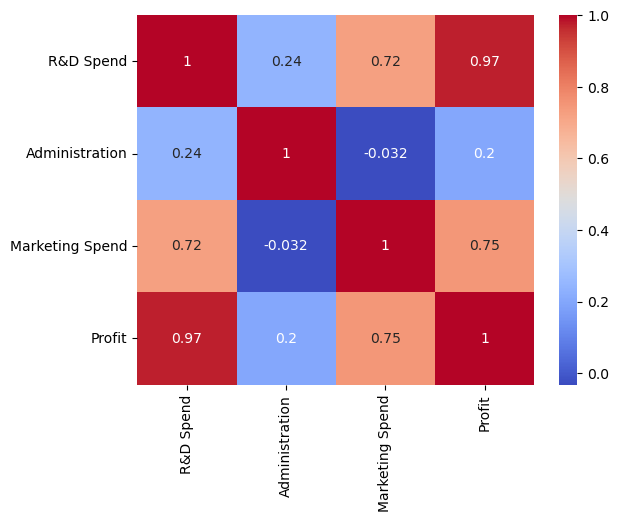

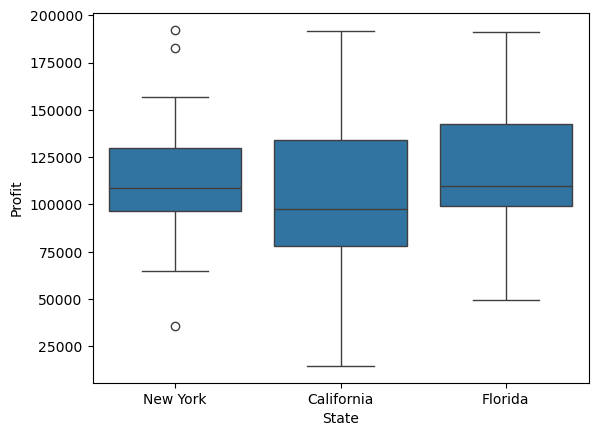

In [5]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,cmap="coolwarm")
plt.show()

sns.boxplot(x='State',y='Profit',data=df)
plt.show()

#### insight
- R&D Spend has strong positive correlation with profit.
- Marketing spend also shows moderate correlation.
- Administration has weak correlation.
- In the New York state category, a few data points are identified as outliers (represented by small circular markers).
- These outliers indicate variability in profit among startups in New York.

In [6]:
df = pd.get_dummies(df,columns=['State'],drop_first=True)

In [7]:
X = df.drop('Profit',axis=1)
y = df['Profit']

In [8]:
#### Train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Model Building (Multiple Models for R^2 Table)


In [9]:
### Basic Linear Regression

model1 = LinearRegression()
model1.fit(X_train,y_train)

y_pred1 = model1.predict(X_test)

r2_score1 = r2_score(y_test,y_pred1)
rmse_1 = np.sqrt(mean_squared_error(y_test,y_pred1))

print("r2_score1:",r2_score1)
print("rmse_1:",rmse_1)

r2_score1: 0.8987266414328636
rmse_1: 9055.957323458471


In [10]:
#### Log Transformation

y_log = np.log(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

r2_score2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test,y_pred2))

print("r2_score2:",r2_score2)
print("rmse_2:",rmse_2)

r2_score2: 0.7013203713256264
rmse_2: 0.20527883192457214


#### Removing Weak Feature (Administration)

In [11]:
X_new = X.drop('Administration', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

r2_score3 = r2_score(y_test, y_pred3)
rmse_3 = np.sqrt(mean_squared_error(y_test,y_pred3))

print("r2_score3:",r2_score3)
print("rmse_3:",rmse_3)

r2_score3: 0.9158551276280779
rmse_3: 8254.686589386354


#### R^2 Comparison Table

In [12]:
results = pd.DataFrame({'Model':['Basic Linear','Log Model','Removed Admin'],
                        'R2_Score':[r2_score1,r2_score2,r2_score3]
                       }
                      )
results

,Model,R2_Score
0,Basic Linear,0.898727
1,Log Model,0.701320
2,Removed Admin,0.915855


### insight
- Model with highest R^2 is selected as final model.
- Removing weak Features improved performance slightly.

#### Final Model

In [13]:
final_model =model3

final_predictions = final_model.predict(X_test)

In [14]:
output = pd.DataFrame({
    'Actual':y_test,
    'Predicted':final_predictions
})

output.to_csv(r"C:\Users\mahesh\Documents\Assignment_2\50_Startups_Predictions.csv",index = False)

### conclusion

- R&D Spend is the most important factor affecting profit.
- Marketing Spend also contributes positively.
- Administration has minimal impact.
- Final model achieved strong R^2 score indicating good predictive performance.